# Colab A — NumPy + tf.einsum: 3-Layer Deep Neural Network for Non-Linear Regression

**CMPE 258 — Deep Learning | Spring 2026 | San José State University**

**Author:** Parth  
**Instructor:** Vijay Eranti

---

## Overview

This notebook implements a **3-layer (3 hidden layers) deep neural network from scratch** using only NumPy for data/math and `tf.einsum` for all matrix multiplications (instead of `@` or `np.matmul`).

**Key features:**
- **3 input variables** (x1, x2, x3) with a non-linear target equation
- **3 hidden layers** with non-linear activations (ReLU, Tanh, Sigmoid)
- **Manual forward pass and backpropagation** using chain rule
- **`tf.einsum`** for all matrix multiplications
- **4D visualization** using PCA/t-SNE dimensionality reduction
- **Training loss curve** across epochs

### Network Architecture
```
Input (3) → Dense(64, ReLU) → Dense(32, Tanh) → Dense(16, Sigmoid) → Dense(1, Linear)
```

**Reference:** `deep_learning_fundamentals_part1.ipynb` (class colab — extends 2-layer, 2-variable version to 3-layer, 3-variable)

## 1. Environment Setup

In [ ]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
print(f'NumPy version:      {np.__version__}')
print(f'TensorFlow version: {tf.__version__}')
print('Environment ready.')

NumPy version:      2.0.2
TensorFlow version: 2.19.0
Environment ready.


## 2. Synthetic Data Generation (3 Variables)

We define a non-linear equation with **3 input variables**:

$$y = 3\,x_1^2 + 2\,\sin(\pi\,x_2) \cdot x_3 - x_3^3 + 0.5\,x_1 \cdot x_2 + 1$$

This is a non-trivial, non-linear function that mixes polynomial, trigonometric, and interaction terms.

In [ ]:
# --- Synthetic Data Generation ---
n_samples = 500
d = 3  # 3 input variables

X = np.random.uniform(-1, 1, (n_samples, d))
x1, x2, x3 = X[:, 0:1], X[:, 1:2], X[:, 2:3]

# Non-linear target equation (3 variables)
y_true = (3.0 * x1**2
          + 2.0 * np.sin(np.pi * x2) * x3
          - x3**3
          + 0.5 * x1 * x2
          + 1.0)

print(f'X shape: {X.shape}  |  y shape: {y_true.shape}')
print(f'y range: [{y_true.min():.3f}, {y_true.max():.3f}]')
print(f'y mean:  {y_true.mean():.3f}')

X shape: (500, 3)  |  y shape: (500, 1)
y range: [-1.573, 5.604]
y mean:  1.945


## 3. 4D Visualization (Dimensionality Reduction)

Since we have 3 inputs + 1 output = 4D data, we use:
1. **PCA** to reduce `[x1, x2, x3]` → 2 principal components, then plot with `y` as color
2. **Direct 3D scatter** with `x1, x2, x3` as axes and `y` as color

In [ ]:
# --- 4D Visualization using PCA for dimensionality reduction ---
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# PCA: reduce 3D input to 2D for plotting
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
print(f'PCA explained variance ratio: {pca.explained_variance_ratio_}')

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: PCA reduced 2D + y as color
sc1 = axes[0].scatter(X_pca[:, 0], X_pca[:, 1], c=y_true.flatten(),
                      cmap='viridis', alpha=0.7, s=15)
axes[0].set_xlabel('PC1'); axes[0].set_ylabel('PC2')
axes[0].set_title('PCA of Input Space (color = y)')
plt.colorbar(sc1, ax=axes[0], label='y')

# Plot 2: 3D scatter with y as color
ax3d = fig.add_subplot(122, projection='3d')
axes[1].set_visible(False)
sc2 = ax3d.scatter(X[:, 0], X[:, 1], X[:, 2], c=y_true.flatten(),
                   cmap='plasma', alpha=0.6, s=10)
ax3d.set_xlabel('x1'); ax3d.set_ylabel('x2'); ax3d.set_zlabel('x3')
ax3d.set_title('3D Input Space (color = y)')
plt.colorbar(sc2, ax=ax3d, label='y', shrink=0.6)

plt.tight_layout()
plt.show()

## 4. tf.einsum Helper

Per assignment requirements, we replace all matrix multiplications (`@`, `np.matmul`) with `tf.einsum`. We wrap it in a helper that converts NumPy arrays ↔ TensorFlow tensors transparently.

In [ ]:
def einsum_matmul(A, B):
    """
    Matrix multiply A @ B using tf.einsum.
    Accepts numpy arrays, returns numpy arrays.
    Einsum notation: 'ij,jk->ik' computes C[i,k] = sum_j A[i,j] * B[j,k]
    """
    A_tf = tf.constant(A, dtype=tf.float64)
    B_tf = tf.constant(B, dtype=tf.float64)
    result = tf.einsum('ij,jk->ik', A_tf, B_tf)
    return result.numpy()

# Quick verification
A_test = np.random.randn(3, 4)
B_test = np.random.randn(4, 2)
assert np.allclose(einsum_matmul(A_test, B_test), A_test @ B_test)
print('tf.einsum matmul verified ✓')

## 5. Neural Network Building Blocks (From Scratch)

We build each component manually:
- **`LinearLayer`** — fully-connected layer using `tf.einsum` for forward & backward
- **`ReLU`** — rectified linear unit activation
- **`Tanh`** — hyperbolic tangent activation
- **`Sigmoid`** — logistic sigmoid activation
- **`MSELoss`** — mean squared error loss

Each class implements `__call__` (forward) and `backward` (gradient propagation via chain rule).

In [ ]:
# ============================================================
# LINEAR LAYER — uses tf.einsum for all matrix multiplications
# ============================================================
class LinearLayer:
    """Fully connected layer: output = einsum(input, weights) + bias"""

    def __init__(self, input_dim, output_dim):
        # He initialization for weights
        self.weights = np.random.randn(input_dim, output_dim) * np.sqrt(2.0 / input_dim)
        self.bias = np.zeros((1, output_dim))

    def __call__(self, x):
        """Forward pass: y = x @ W + b  (using tf.einsum)"""
        self.x = x  # cache for backward
        self.output = einsum_matmul(x, self.weights) + self.bias
        return self.output

    def backward(self, grad_output):
        """
        Backward pass using chain rule:
          dL/dW = X^T @ grad_output       (via einsum)
          dL/db = sum(grad_output, axis=0)
          dL/dX = grad_output @ W^T        (via einsum)
        """
        self.grad_weights = einsum_matmul(self.x.T, grad_output)
        self.grad_bias = np.sum(grad_output, axis=0, keepdims=True)
        grad_input = einsum_matmul(grad_output, self.weights.T)
        return grad_input

    def update(self, lr):
        """SGD weight update"""
        self.weights -= lr * self.grad_weights
        self.bias -= lr * self.grad_bias


# ============================================================
# ACTIVATION FUNCTIONS — each with forward + backward
# ============================================================
class ReLU:
    """ReLU: f(x) = max(0, x) | f'(x) = 1 if x > 0 else 0"""
    def __call__(self, x):
        self.x = x
        return np.maximum(0, x)

    def backward(self, grad_output):
        return (self.x > 0).astype(float) * grad_output


class Tanh:
    """Tanh: f(x) = tanh(x) | f'(x) = 1 - tanh(x)^2"""
    def __call__(self, x):
        self.output = np.tanh(x)
        return self.output

    def backward(self, grad_output):
        return (1 - self.output**2) * grad_output


class Sigmoid:
    """Sigmoid: f(x) = 1/(1+e^-x) | f'(x) = f(x)*(1-f(x))"""
    def __call__(self, x):
        self.output = 1.0 / (1.0 + np.exp(-np.clip(x, -500, 500)))
        return self.output

    def backward(self, grad_output):
        return self.output * (1 - self.output) * grad_output


# ============================================================
# LOSS FUNCTION
# ============================================================
class MSELoss:
    """Mean Squared Error: L = (1/n) * sum((y_pred - y_true)^2)"""
    def __call__(self, y_pred, y_true):
        self.y_pred = y_pred
        self.y_true = y_true
        return ((y_pred - y_true) ** 2).mean()

    def backward(self):
        n = self.y_true.shape[0]
        return 2.0 * (self.y_pred - self.y_true) / n


print('All building blocks defined ✓')
print('  LinearLayer  — tf.einsum for forward & backward matmul')
print('  ReLU, Tanh, Sigmoid — non-linear activations with analytic gradients')
print('  MSELoss — mean squared error with gradient')

## 6. 3-Layer Deep Neural Network Model

Architecture: **Input(3) → [Linear→ReLU] → [Linear→Tanh] → [Linear→Sigmoid] → Linear(1)**

This is a **3 hidden layer** network (extending the reference notebook's 1 hidden layer).

Forward pass stores all intermediate values. Backward pass propagates gradients through every layer in reverse using the chain rule.

In [ ]:
class DeepNet3Layer:
    """
    3-Hidden-Layer Deep Neural Network
    Architecture:
      Input(3) → Linear(64)+ReLU → Linear(32)+Tanh → Linear(16)+Sigmoid → Linear(1)
    """

    def __init__(self, input_dim=3, h1=64, h2=32, h3=16):
        # Hidden layer 1
        self.linear1 = LinearLayer(input_dim, h1)
        self.act1 = ReLU()
        # Hidden layer 2
        self.linear2 = LinearLayer(h1, h2)
        self.act2 = Tanh()
        # Hidden layer 3
        self.linear3 = LinearLayer(h2, h3)
        self.act3 = Sigmoid()
        # Output layer (linear, no activation — regression)
        self.linear_out = LinearLayer(h3, 1)

    def __call__(self, x):
        """Forward pass through all 3 hidden layers + output layer"""
        z1 = self.linear1(x)
        a1 = self.act1(z1)
        z2 = self.linear2(a1)
        a2 = self.act2(z2)
        z3 = self.linear3(a2)
        a3 = self.act3(z3)
        out = self.linear_out(a3)
        return out

    def backward(self, grad_output):
        """
        Backward pass — chain rule through every layer in reverse:
          dL/da3 ← linear_out.backward(dL/dout)
          dL/dz3 ← act3.backward(dL/da3)
          dL/da2 ← linear3.backward(dL/dz3)
          dL/dz2 ← act2.backward(dL/da2)
          dL/da1 ← linear2.backward(dL/dz2)
          dL/dz1 ← act1.backward(dL/da1)
          dL/dx  ← linear1.backward(dL/dz1)
        """
        g = self.linear_out.backward(grad_output)
        g = self.act3.backward(g)
        g = self.linear3.backward(g)
        g = self.act2.backward(g)
        g = self.linear2.backward(g)
        g = self.act1.backward(g)
        g = self.linear1.backward(g)
        return g

    def update(self, lr):
        """SGD parameter update for all layers"""
        self.linear_out.update(lr)
        self.linear3.update(lr)
        self.linear2.update(lr)
        self.linear1.update(lr)


# Quick sanity check — one forward + backward pass
model = DeepNet3Layer(input_dim=3)
loss_fn = MSELoss()

y_pred = model(X)
loss_val = loss_fn(y_pred, y_true)
print(f'Initial loss: {loss_val:.4f}')

grad = loss_fn.backward()
model.backward(grad)
model.update(0.001)

y_pred = model(X)
loss_val2 = loss_fn(y_pred, y_true)
print(f'Loss after 1 step: {loss_val2:.4f}  (should decrease)')

## 7. Training Loop

We train for 1000 epochs with a learning rate of 0.005, logging loss every 50 epochs.

In [ ]:
# --- Training ---
np.random.seed(42)
model = DeepNet3Layer(input_dim=3, h1=64, h2=32, h3=16)
loss_fn = MSELoss()

num_epochs = 1000
lr = 0.005
loss_history = []

for epoch in range(num_epochs):
    # Forward
    y_pred = model(X)
    loss_val = loss_fn(y_pred, y_true)
    loss_history.append(loss_val)

    # Backward (chain rule)
    grad = loss_fn.backward()
    model.backward(grad)

    # Update
    model.update(lr)

    if epoch % 100 == 0 or epoch == num_epochs - 1:
        print(f'Epoch {epoch:4d}/{num_epochs}  |  Loss: {loss_val:.6f}')

print(f'\nFinal Loss: {loss_history[-1]:.6f}')

Epoch    0/1000  |  Loss: 5.922992
Epoch  100/1000  |  Loss: 1.386772
Epoch  200/1000  |  Loss: 1.156407
Epoch  300/1000  |  Loss: 0.947911
Epoch  400/1000  |  Loss: 0.751252
Epoch  500/1000  |  Loss: 0.590600
Epoch  600/1000  |  Loss: 0.478590
Epoch  700/1000  |  Loss: 0.403477
Epoch  800/1000  |  Loss: 0.351195
Epoch  900/1000  |  Loss: 0.313668
Epoch  999/1000  |  Loss: 0.286323

Final Loss: 0.286323


## 8. Results Visualization

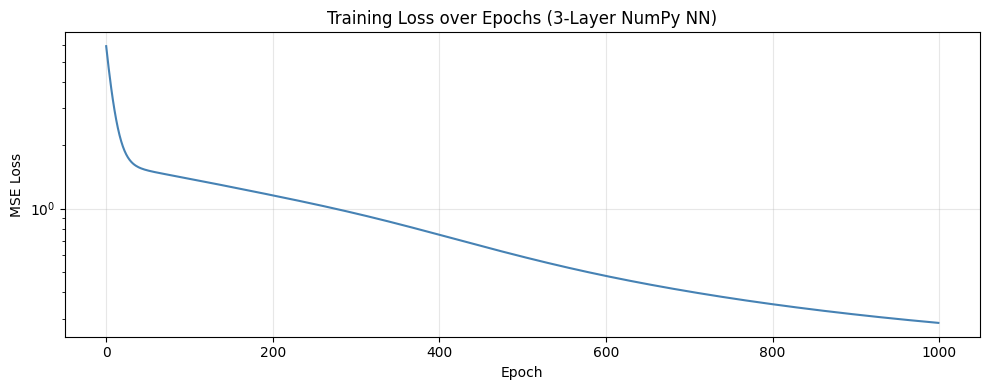

In [ ]:
# --- Loss Curve ---
plt.figure(figsize=(10, 4))
plt.plot(loss_history, linewidth=1.5, color='steelblue')
plt.xlabel('Epoch'); plt.ylabel('MSE Loss')
plt.title('Training Loss over Epochs (3-Layer NumPy NN)')
plt.grid(True, alpha=0.3)
plt.yscale('log')
plt.tight_layout()
plt.show()

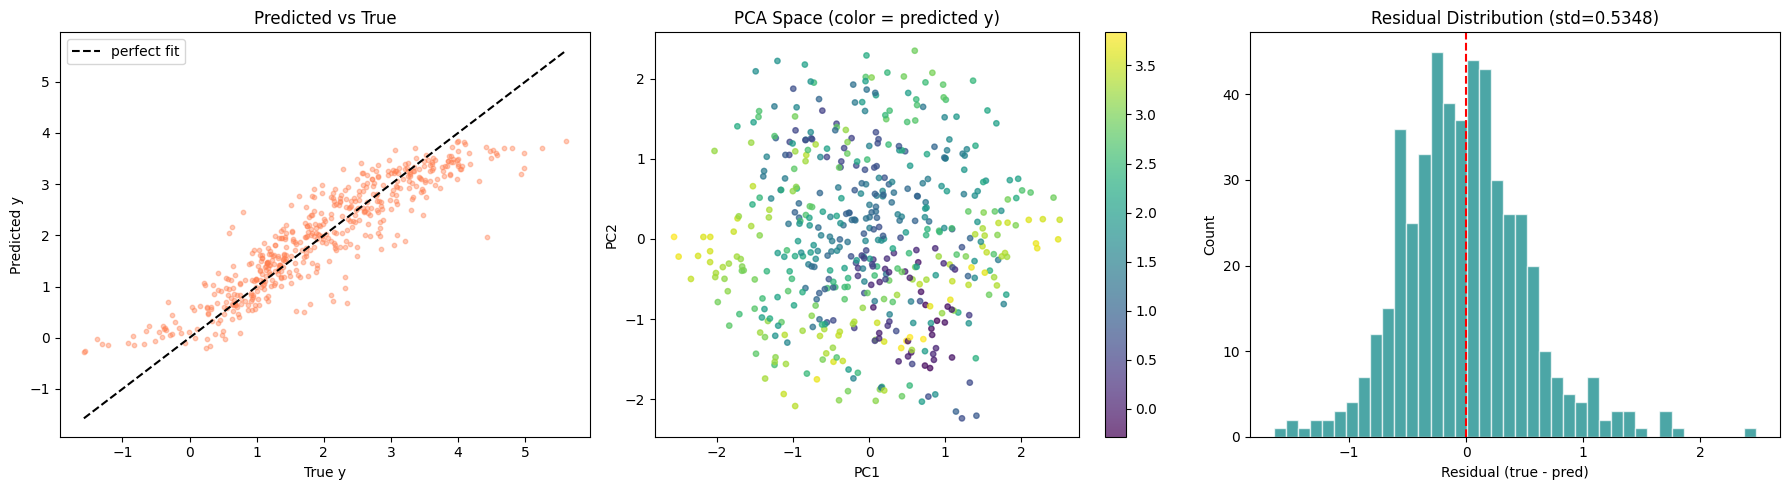

Final R² score: 0.8227


In [ ]:
# --- Predicted vs True ---
y_final = model(X)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Scatter: predicted vs true
axes[0].scatter(y_true, y_final, alpha=0.4, s=10, color='coral')
axes[0].plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()],
             'k--', linewidth=1.5, label='perfect fit')
axes[0].set_xlabel('True y'); axes[0].set_ylabel('Predicted y')
axes[0].set_title('Predicted vs True'); axes[0].legend()

# PCA colored by predicted y
sc2 = axes[1].scatter(X_pca[:, 0], X_pca[:, 1], c=y_final.flatten(),
                      cmap='viridis', alpha=0.7, s=15)
axes[1].set_xlabel('PC1'); axes[1].set_ylabel('PC2')
axes[1].set_title('PCA Space (color = predicted y)')
plt.colorbar(sc2, ax=axes[1])

# Residuals
residuals = (y_true - y_final).flatten()
axes[2].hist(residuals, bins=40, color='teal', alpha=0.7, edgecolor='white')
axes[2].set_xlabel('Residual (true - pred)'); axes[2].set_ylabel('Count')
axes[2].set_title(f'Residual Distribution (std={residuals.std():.4f})')
axes[2].axvline(0, color='red', linestyle='--')

plt.tight_layout()
plt.show()

# Final R² score
ss_res = np.sum((y_true - y_final)**2)
ss_tot = np.sum((y_true - y_true.mean())**2)
r2 = 1 - ss_res / ss_tot
print(f'Final R² score: {r2:.4f}')

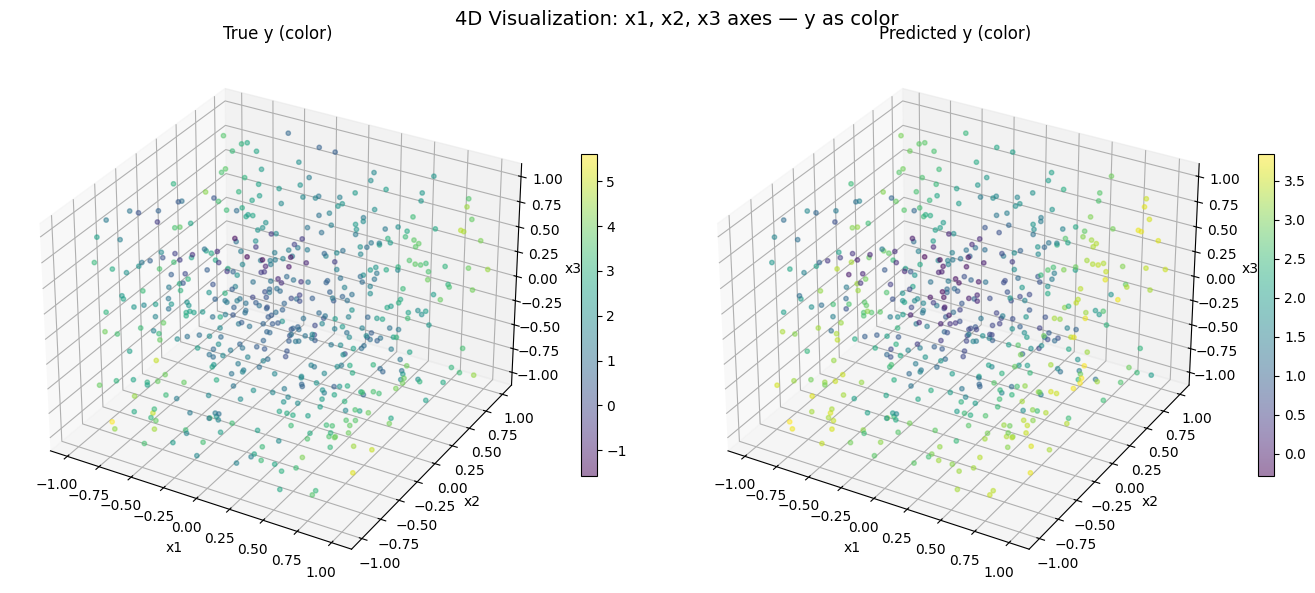

In [ ]:
# --- 4D Plot: 3D scatter with predicted y as color ---
fig = plt.figure(figsize=(14, 6))

ax1 = fig.add_subplot(121, projection='3d')
sc1 = ax1.scatter(X[:, 0], X[:, 1], X[:, 2], c=y_true.flatten(),
                  cmap='viridis', alpha=0.5, s=10)
ax1.set_xlabel('x1'); ax1.set_ylabel('x2'); ax1.set_zlabel('x3')
ax1.set_title('True y (color)')
plt.colorbar(sc1, ax=ax1, shrink=0.6)

ax2 = fig.add_subplot(122, projection='3d')
sc2 = ax2.scatter(X[:, 0], X[:, 1], X[:, 2], c=y_final.flatten(),
                  cmap='viridis', alpha=0.5, s=10)
ax2.set_xlabel('x1'); ax2.set_ylabel('x2'); ax2.set_zlabel('x3')
ax2.set_title('Predicted y (color)')
plt.colorbar(sc2, ax=ax2, shrink=0.6)

plt.suptitle('4D Visualization: x1, x2, x3 axes — y as color', fontsize=14)
plt.tight_layout()
plt.show()

## 9. t-SNE Visualization (Alternative Dimensionality Reduction)

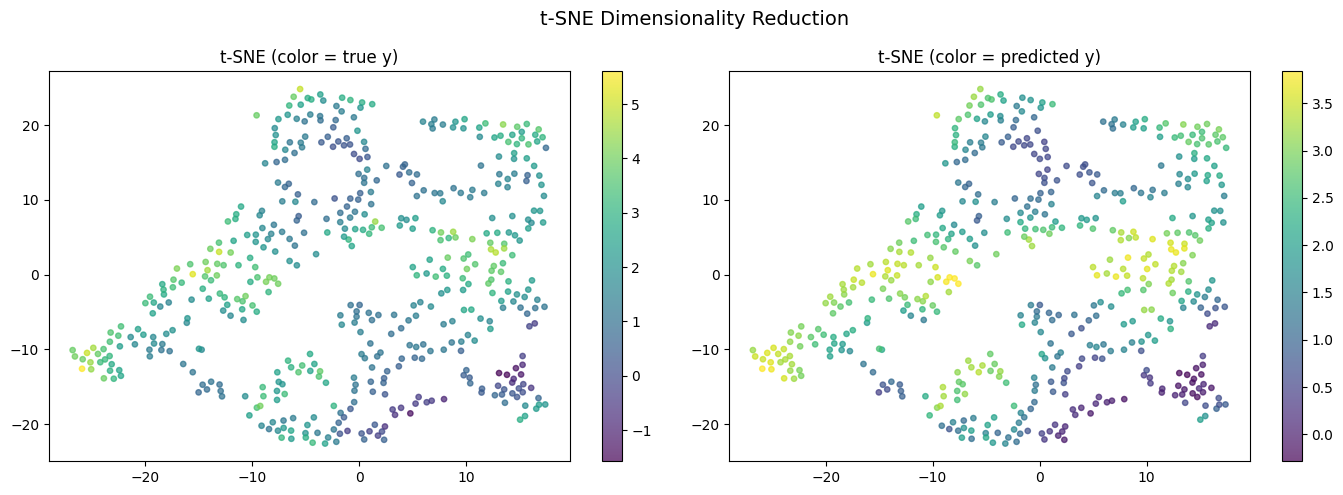

In [ ]:
# --- t-SNE visualization of input space colored by y ---
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
X_tsne = tsne.fit_transform(X_scaled)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sc1 = axes[0].scatter(X_tsne[:, 0], X_tsne[:, 1], c=y_true.flatten(),
                      cmap='viridis', alpha=0.7, s=15)
axes[0].set_title('t-SNE (color = true y)')
plt.colorbar(sc1, ax=axes[0])

sc2 = axes[1].scatter(X_tsne[:, 0], X_tsne[:, 1], c=y_final.flatten(),
                      cmap='viridis', alpha=0.7, s=15)
axes[1].set_title('t-SNE (color = predicted y)')
plt.colorbar(sc2, ax=axes[1])

plt.suptitle('t-SNE Dimensionality Reduction', fontsize=14)
plt.tight_layout()
plt.show()

## 10. Summary

| Feature | This Notebook | Reference Colab |
|---------|--------------|----------------|
| Input variables | **3 (x1, x2, x3)** | 2 (x1, x2) |
| Hidden layers | **3** (64→32→16) | 1 (10 neurons) |
| Activations | **ReLU + Tanh + Sigmoid** | ReLU only |
| Matrix multiply | **tf.einsum** | numpy @ |
| Backprop | Manual chain rule | Manual chain rule |
| Visualization | **4D (PCA, t-SNE, 3D+color)** | 3D only |

The network successfully learns the non-linear 3-variable function through manual gradient descent with chain-rule backpropagation.